In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, accuracy_score

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

In [63]:
df = pd.read_csv('final_dataset/binary_label_encoded.csv')

In [64]:
X = df.iloc[:, 0:19].values
y = df.iloc[:, -1].values

In [65]:
# one hot encoding for "Race" and "District"

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [4, 5])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [67]:
# feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [68]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 1)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=1)

In [69]:
y_pred_dt = classifier.predict(X_test)
print(np.concatenate((y_pred_dt.reshape(len(y_pred_dt),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [70]:
# confusion matrix and accuracy for Decision Tree

cm = confusion_matrix(y_test, y_pred_dt)
print(cm)
accuracy_score(y_test, y_pred_dt)

[[82533  1349]
 [ 1205  2393]]


0.9708047553726566

In [71]:
# 10 fold cross validation for Decision Tree

from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 96.99 %
Standard Deviation: 0.13 %


In [72]:
# training with random forest classification

from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [73]:
y_pred_rf = classifier.predict(X_test)
print(np.concatenate((y_pred_rf.reshape(len(y_pred_rf),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [74]:
# confusion matrix for random forest classifier

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
accuracy_score(y_test, y_pred_rf)

[[83762   120]
 [ 1985  1613]]


0.9759373571101966

In [75]:
# 10 fold cross validation for Random Forest

from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 97.62 %
Standard Deviation: 0.08 %


In [76]:
# training with logistic regression

from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 1)
classifier.fit(X_train, y_train)

C:\Users\14104\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=1)

In [77]:
# predict test result with logistic regression

y_pred_lr = classifier.predict(X_test)
print(np.concatenate((y_pred_lr.reshape(len(y_pred_lr),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [78]:
# confusion matrix for logistic regression

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)
accuracy_score(y_test, y_pred_lr)

[[83872    10]
 [ 3586    12]]


0.9588934613625971

In [79]:
# 10 fold cross validation for Logistic Regression

from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

C:\Users\14104\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\14104\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy: 95.90 %
Standard Deviation: 0.01 %


C:\Users\14104\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [80]:
# training on K-NN

from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 1000, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1000)

In [81]:
y_pred_knn = classifier.predict(X_test)
#print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

In [82]:
# confusion matrix and accuracy score for K-NN

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred_knn)
print(cm)
accuracy_score(y_test, y_pred_knn)

[[83882     0]
 [ 3598     0]]


0.9588705989940558

In [83]:
# 10 fold cross validation for K-NN

from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 95.91 %
Standard Deviation: 0.00 %


In [84]:
# training on bayesian network

from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [85]:
y_pred_bn = classifier.predict(X_test)
#print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

In [86]:
# confusion matrix and accuracy of bayesian network

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred_bn)
print(cm)
accuracy_score(y_test, y_pred_bn)

[[15719 68163]
 [  160  3438]]


0.21898719707361683

In [87]:
# 10 fold cross validation for Bayesian Network

from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 21.71 %
Standard Deviation: 0.57 %


In [88]:
#keras.wrappers is use to implement the k-cross validation
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from keras.models import Sequential
from keras.layers import Dense

In [89]:
def build_classifier():
	classifier = Sequential()
	
	classifier.add(Dense(
		units = 128,
		activation="relu",
		))
	
	classifier.add(Dense(
		units = 128,
		activation="relu"
		))
	
	classifier.add(Dense(
		units = 1,
		activation="sigmoid"
		))
	
	classifier.compile(
		optimizer = "adam",
		loss="binary_crossentropy",
		metrics=['accuracy']
		)
	
	return classifier

In [90]:
#this classifier will be use to the 10 different training fold 
#for k-cross validation on 1 test fold
classifier = KerasClassifier(build_fn = build_classifier,
							 batch_size = 32,
							 nb_epoch = 100 )
classifier

C:\Users\14104\AppData\Local\Temp\ipykernel_4300\385065381.py:3: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  classifier = KerasClassifier(build_fn = build_classifier,


In [91]:
accuracies = cross_val_score(
		estimator=classifier,
		X = X_train,
		y = y_train,
		cv=10
		)

638/638 [==============================] - 1s 1ms/step - loss: 0.1600 - accuracy: 0.9576


In [92]:
#after we got the accuracies, find the mean
mean = accuracies.mean()
variance = accuracies.std()

In [93]:
# mean from 10 fold cross validation of Neural Network
mean

0.9590926945209504

In [94]:
# std from 10 fold cross validation of Neural Network
variance

0.00151317715950057

In [95]:
# another way to implement ANN
ann = tf.keras.models.Sequential()

In [96]:
# adding first hidden layer
ann.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [97]:
# adding second hidden layer
ann.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [98]:
# adding output layer
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [99]:
# compiling the ANN
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [100]:
ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
6379/6379 [==============================] - 8s 1ms/step - loss: 0.1591 - accuracy: 0.9589
Epoch 2/100
6379/6379 [==============================] - 10s 2ms/step - loss: 0.1547 - accuracy: 0.9592
Epoch 3/100
6379/6379 [==============================] - 11s 2ms/step - loss: 0.1520 - accuracy: 0.9594
Epoch 4/100
6379/6379 [==============================] - 11s 2ms/step - loss: 0.1500 - accuracy: 0.9595
Epoch 5/100
6379/6379 [==============================] - 12s 2ms/step - loss: 0.1488 - accuracy: 0.9595
Epoch 6/100
6379/6379 [==============================] - 12s 2ms/step - loss: 0.1480 - accuracy: 0.9595
Epoch 7/100
6379/6379 [==============================] - 12s 2ms/step - loss: 0.1473 - accuracy: 0.9596
Epoch 8/100
6379/6379 [==============================] - 11s 2ms/step - loss: 0.1468 - accuracy: 0.9596
Epoch 9/100
6379/6379 [==============================] - 12s 2ms/step - loss: 0.1463 - accuracy: 0.9596
Epoch 10/100
6379/6379 [==============================] - 12s 2ms

6379/6379 [==============================] - 10s 2ms/step - loss: 0.0879 - accuracy: 0.9771
Epoch 80/100
6379/6379 [==============================] - 10s 2ms/step - loss: 0.0867 - accuracy: 0.9772
Epoch 81/100
6379/6379 [==============================] - 11s 2ms/step - loss: 0.0877 - accuracy: 0.9770
Epoch 82/100
6379/6379 [==============================] - 10s 2ms/step - loss: 0.0859 - accuracy: 0.9775
Epoch 83/100
6379/6379 [==============================] - 12s 2ms/step - loss: 0.0883 - accuracy: 0.9773
Epoch 84/100
6379/6379 [==============================] - 10s 2ms/step - loss: 0.0860 - accuracy: 0.9774
Epoch 85/100
6379/6379 [==============================] - 10s 2ms/step - loss: 0.0864 - accuracy: 0.9772
Epoch 86/100
6379/6379 [==============================] - 11s 2ms/step - loss: 0.0871 - accuracy: 0.9775
Epoch 87/100
6379/6379 [==============================] - 11s 2ms/step - loss: 0.0869 - accuracy: 0.9773
Epoch 88/100
6379/6379 [==============================] - 11s 2ms/st

In [101]:
# predicting the test results
y_pred_nn = ann.predict(X_test)
y_pred_nn = (y_pred_nn > 0.5)
print(np.concatenate((y_pred_nn.reshape(len(y_pred_nn),1), y_test.reshape(len(y_test),1)),1))

2734/2734 [==============================] - 2s 811us/step
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [102]:
# making confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred_nn)
print(cm)
accuracy_score(y_test, y_pred_nn)

[[83615   267]
 [ 2456  1142]]


0.96887288523091

In [103]:
# computing AUROC and ROC curve values

from sklearn.metrics import roc_curve, roc_auc_score
dt_auc = roc_auc_score(y_test, y_pred_dt)
rf_auc = roc_auc_score(y_test, y_pred_rf)
lr_auc = roc_auc_score(y_test, y_pred_lr)
nn_auc = roc_auc_score(y_test, y_pred_nn)
knn_auc = roc_auc_score(y_test, y_pred_knn)
bn_auc = roc_auc_score(y_test, y_pred_bn)

In [104]:
# printing AUROC scores

print('Decision tree: AUROC = %.3f' % (dt_auc))
print('Random forest: AUROC = %.3f' % (rf_auc))
print('Logistic regression: AUROC = %.3f' % (lr_auc))
print('Neural network: AUROC = %.3f' % (nn_auc))
print('K-Nearest neighbor: AUROC = %.3f' % (knn_auc))
print('Bayesian network: AUROC = %.3f' % (bn_auc))

Decision tree: AUROC = 0.825
Random forest: AUROC = 0.723
Logistic regression: AUROC = 0.502
Neural network: AUROC = 0.657
K-Nearest neighbor: AUROC = 0.500
Bayesian network: AUROC = 0.571


In [105]:
# calculate ROC curve

dt_fpr, dt_tpr, _ = roc_curve(y_test, y_pred_dt)
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_pred_rf)
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_pred_lr)
nn_fpr, nn_tpr, _ = roc_curve(y_test, y_pred_nn)
knn_fpr, knn_tpr, _ = roc_curve(y_test, y_pred_knn)
bn_fpr, bn_tpr, _ = roc_curve(y_test, y_pred_bn)

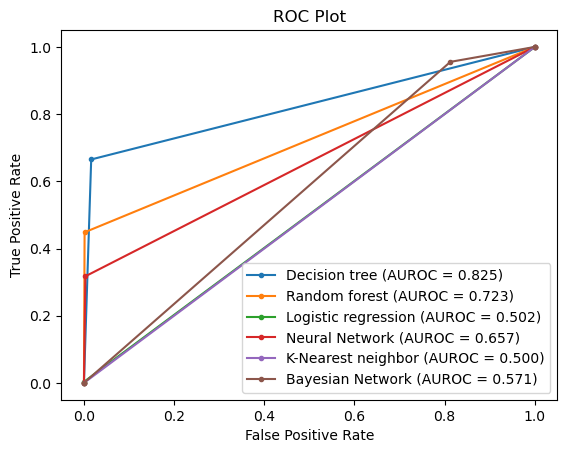

In [106]:
# plotting ROC curve

plt.plot(dt_fpr, dt_tpr, marker='.', label='Decision tree (AUROC = %0.3f)' % dt_auc)
plt.plot(rf_fpr, rf_tpr, marker='.', label='Random forest (AUROC = %0.3f)' % rf_auc)
plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic regression (AUROC = %0.3f)' % lr_auc)
plt.plot(nn_fpr, nn_tpr, marker='.', label='Neural Network (AUROC = %0.3f)' % nn_auc)
plt.plot(knn_fpr, knn_tpr, marker='.', label='K-Nearest neighbor (AUROC = %0.3f)' % knn_auc)
plt.plot(bn_fpr, bn_tpr, marker='.', label='Bayesian Network (AUROC = %0.3f)' % bn_auc)

# Title
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() # 
# Show plot
plt.show()